# **Global Health Indicators – EDA Report**
## **Introduction**
This project explores global public health patterns using the Life Expectancy dataset. The goal is to understand key factors influencing life expectancy and the relationship between vaccination rates and disease prevalence.

## **Dataset Description**
The dataset contains information about life expectancy, socioeconomic indicators, mortality rates, vaccination coverage, and other health-related variables for different countries across multiple years.

## **Research Questions**
1. **Which factors most strongly influence Life Expectancy across countries?**
2. **Are vaccination rates (Polio, Measles, Hepatitis B) associated with measurable declines in disease prevalence over time?**


# **Importing libraries and loading the dataset**

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("/content/drive/MyDrive/Life Expectancy Data.csv")
df.head()

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


# **Cleaning column names**

In [39]:
df.columns = df.columns.str.strip()
df.columns = df.columns.str.replace(' ', '_')
print(df.columns)

Index(['Country', 'Year', 'Status', 'Life_expectancy', 'Adult_Mortality',
       'infant_deaths', 'Alcohol', 'percentage_expenditure', 'Hepatitis_B',
       'Measles', 'BMI', 'under-five_deaths', 'Polio', 'Total_expenditure',
       'Diphtheria', 'HIV/AIDS', 'GDP', 'Population', 'thinness__1-19_years',
       'thinness_5-9_years', 'Income_composition_of_resources', 'Schooling'],
      dtype='object')


# **Exploring the dataset**

In [40]:
print(df.shape)
print(df.info())

(2938, 22)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   object 
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   object 
 3   Life_expectancy                  2928 non-null   float64
 4   Adult_Mortality                  2928 non-null   float64
 5   infant_deaths                    2938 non-null   int64  
 6   Alcohol                          2744 non-null   float64
 7   percentage_expenditure           2938 non-null   float64
 8   Hepatitis_B                      2385 non-null   float64
 9   Measles                          2938 non-null   int64  
 10  BMI                              2904 non-null   float64
 11  under-five_deaths                2938 non-null   int64  
 12  Polio    

# **Checking for null values**

In [41]:
print(df.isna().sum())

Country                              0
Year                                 0
Status                               0
Life_expectancy                     10
Adult_Mortality                     10
infant_deaths                        0
Alcohol                            194
percentage_expenditure               0
Hepatitis_B                        553
Measles                              0
BMI                                 34
under-five_deaths                    0
Polio                               19
Total_expenditure                  226
Diphtheria                          19
HIV/AIDS                             0
GDP                                448
Population                         652
thinness__1-19_years                34
thinness_5-9_years                  34
Income_composition_of_resources    167
Schooling                          163
dtype: int64


# **Data Cleaning**
  **Fill numeric missing values with median and
  Fill categorical missing values with mode**

In [42]:
for col in df.columns:
    if df[col].dtype != 'object':
        df[col] = df[col].fillna(df[col].median())
    else:
        df[col] = df[col].fillna(df[col].mode()[0])
print(df.isna().sum().sum())

0


# **Selecting relevant columns for analysis**

In [43]:
q1_cols = ["Country", "Year", "Life_expectancy", "Income_composition_of_resources",
            "Schooling", "Adult_Mortality", "infant_deaths"]

q1 = df[q1_cols].copy()

q1.head()

,Country,Year,Life_expectancy,Income_composition_of_resources,Schooling,Adult_Mortality,infant_deaths
0,Afghanistan,2015,65.0,0.479,10.1,263.0,62
1,Afghanistan,2014,59.9,0.476,10.0,271.0,64
2,Afghanistan,2013,59.9,0.470,9.9,268.0,66
3,Afghanistan,2012,59.5,0.463,9.8,272.0,69
4,Afghanistan,2011,59.2,0.454,9.5,275.0,71


# **Correlation Heatmap for Q1 Features**

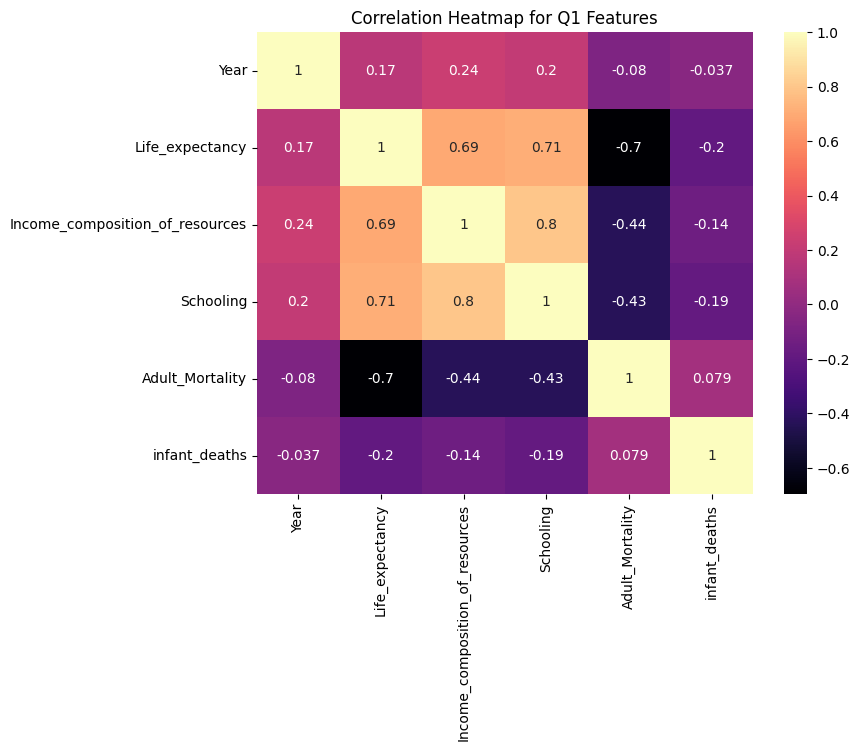

In [44]:
plt.figure(figsize=(8,6))
sns.heatmap(q1.drop(columns=['Country']).corr(), annot=True, cmap="magma")
plt.title("Correlation Heatmap for Q1 Features")
plt.show()

# **Distribution of Life Expectancy**

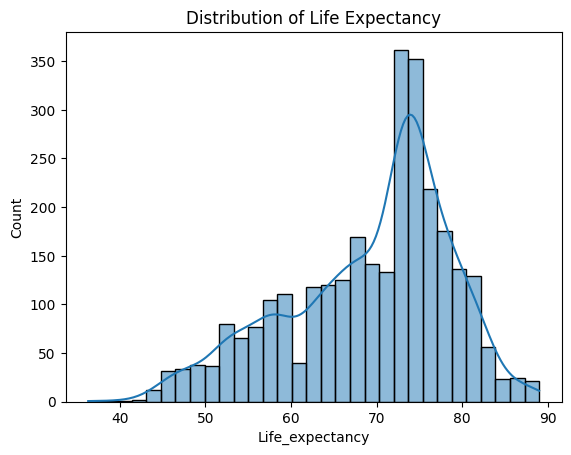

In [45]:
sns.histplot(df["Life_expectancy"], kde=True)
plt.title("Distribution of Life Expectancy")
plt.show()

# **Average Life Expectancy by Status**

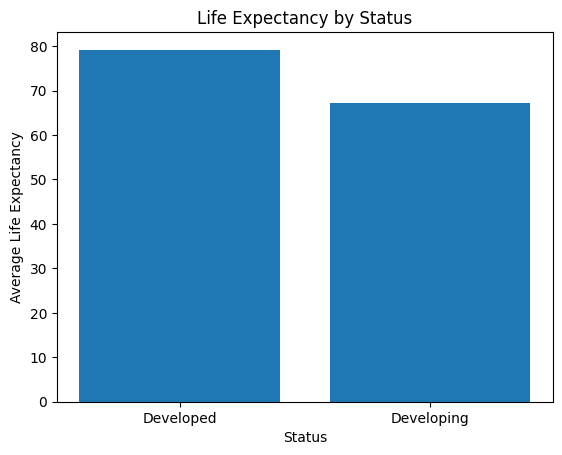

In [46]:
status_avg = df.groupby("Status")["Life_expectancy"].mean()

plt.bar(status_avg.index, status_avg.values)
plt.xlabel("Status")
plt.ylabel("Average Life Expectancy")
plt.title("Life Expectancy by Status")
plt.show()


# **Life Expectancy by Status per Year**

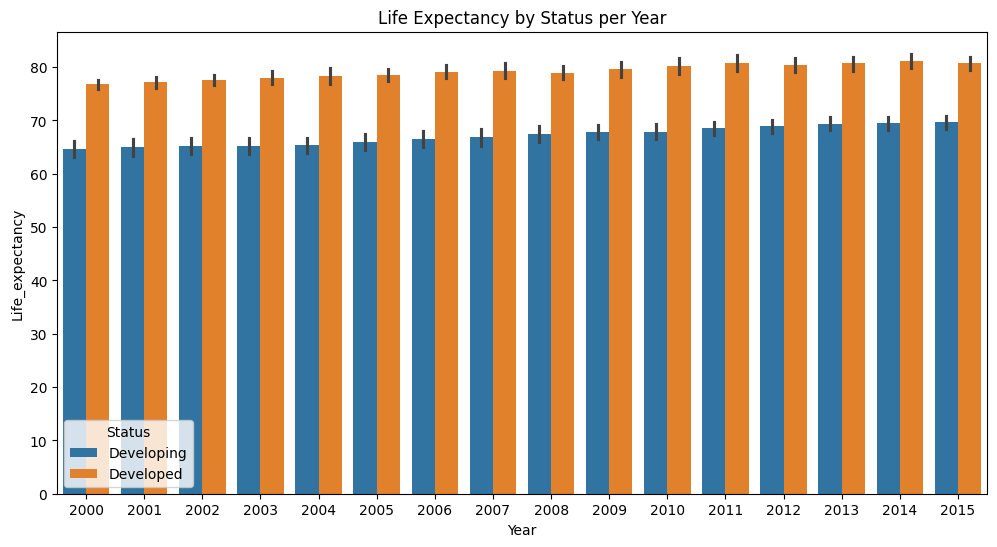

In [47]:
plt.figure(figsize=(12, 6))
sns.barplot(x="Year", y="Life_expectancy", hue="Status", data=df)
plt.title("Life Expectancy by Status per Year")
plt.show()


# **Year-wise Average Life Expectancy**

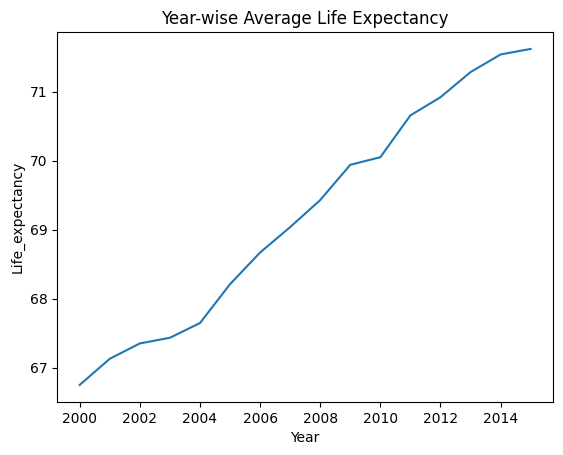

In [48]:
year_avg = df.groupby("Year")["Life_expectancy"].mean().reset_index()
sns.lineplot(data=year_avg, x="Year", y="Life_expectancy")
plt.title("Year-wise Average Life Expectancy")
plt.show()

# **Year-wise Average Vaccination Coverage**

In [49]:
q2_cols = ["Country", "Year", "Polio", "Hepatitis_B", "Measles"]
q2 = df[q2_cols].copy()

q2_yearly = q2.groupby("Year")[["Polio", "Hepatitis_B", "Measles"]].mean()

q2_yearly.head()

,Polio,Hepatitis_B,Measles
Year,,,
2000,76.551913,83.655738,4663.792350
2001,78.196721,82.633880,4640.262295
2002,79.825137,82.442623,3204.754098
2003,80.491803,79.185792,3708.792350
2004,80.306011,81.431694,2805.497268


# **Polio Vaccination Rate Over Years**

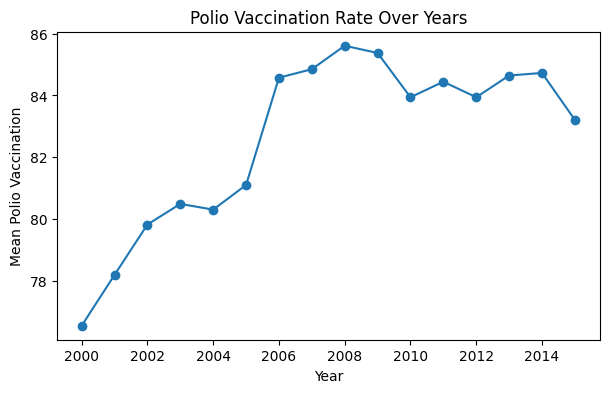

In [50]:
plt.figure(figsize=(7,4))
plt.plot(q2_yearly.index, q2_yearly["Polio"], marker="o")
plt.title("Polio Vaccination Rate Over Years")
plt.xlabel("Year")
plt.ylabel("Mean Polio Vaccination")
plt.show()


# **Hepatitis B Vaccination Rate Over Years**

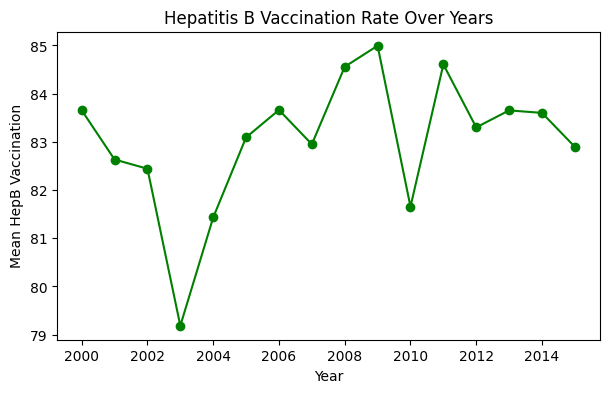

In [51]:
plt.figure(figsize=(7,4))
plt.plot(q2_yearly.index, q2_yearly["Hepatitis_B"], marker="o", color="green")
plt.title("Hepatitis B Vaccination Rate Over Years")
plt.xlabel("Year")
plt.ylabel("Mean HepB Vaccination")
plt.show()

# **Measles Cases Over Years**

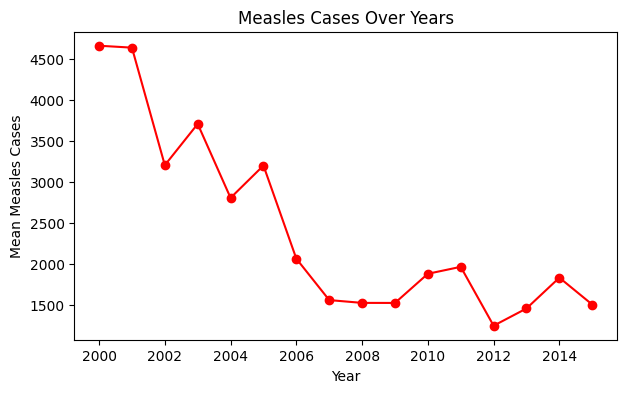

In [52]:
plt.figure(figsize=(7,4))
plt.plot(q2_yearly.index, q2_yearly["Measles"], marker="o", color="red")
plt.title("Measles Cases Over Years")
plt.xlabel("Year")
plt.ylabel("Mean Measles Cases")
plt.show()


In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_disease = pd.read_csv("/content/drive/MyDrive/20220327 annual-number-of-deaths-by-cause.csv")

df_disease.head()

,Entity,Code,Year,Number of executions (Amnesty International),Deaths - Meningitis - Sex: Both - Age: All Ages (Number),Deaths - Neoplasms - Sex: Both - Age: All Ages (Number),"Deaths - Fire, heat, and hot substances - Sex: Both - Age: All Ages (Number)",Deaths - Malaria - Sex: Both - Age: All Ages (Number),Deaths - Drowning - Sex: Both - Age: All Ages (Number),Deaths - Interpersonal violence - Sex: Both - Age: All Ages (Number),...,Deaths - Protein-energy malnutrition - Sex: Both - Age: All Ages (Number),Terrorism (deaths),Deaths - Cardiovascular diseases - Sex: Both - Age: All Ages (Number),Deaths - Chronic kidney disease - Sex: Both - Age: All Ages (Number),Deaths - Chronic respiratory diseases - Sex: Both - Age: All Ages (Number),Deaths - Cirrhosis and other chronic liver diseases - Sex: Both - Age: All Ages (Number),Deaths - Digestive diseases - Sex: Both - Age: All Ages (Number),Deaths - Acute hepatitis - Sex: Both - Age: All Ages (Number),Deaths - Alzheimer's disease and other dementias - Sex: Both - Age: All Ages (Number),Deaths - Parkinson's disease - Sex: Both - Age: All Ages (Number)
0,Afghanistan,AFG,2007,15,2933.0,15925.0,481.0,393.0,2127.0,3657.0,...,2439.0,1199.0,53962.0,4490.0,7222.0,3346.0,6458.0,3437.0,1402.0,450.0
1,Afghanistan,AFG,2008,17,2731.0,16148.0,462.0,255.0,1973.0,3785.0,...,2231.0,1092.0,54051.0,4534.0,7143.0,3316.0,6408.0,3005.0,1424.0,455.0
2,Afghanistan,AFG,2009,0,2460.0,16383.0,448.0,239.0,1852.0,3874.0,...,1998.0,1065.0,53964.0,4597.0,7045.0,3291.0,6358.0,2663.0,1449.0,460.0
3,Afghanistan,AFG,2011,2,2327.0,17094.0,448.0,390.0,1775.0,4170.0,...,1805.0,1525.0,54347.0,4785.0,6916.0,3318.0,6370.0,2365.0,1508.0,473.0
4,Afghanistan,AFG,2012,14,2254.0,17522.0,445.0,94.0,1716.0,4245.0,...,1667.0,3521.0,54868.0,4846.0,6878.0,3353.0,6398.0,2264.0,1544.0,482.0


In [54]:
df_disease.columns = (
    df_disease.columns
        .str.lower()
        .str.replace("deaths - ", "")
        .str.replace(" - sex: both - age: all ages ", "")
        .str.replace("(number)", "")
        .str.replace(" ", "_")
        .str.replace("/", "_")
        .str.replace(",", "")
        .str.replace("'", "")
        .str.replace("-", "_")
        .str.replace("(", "")
        .str.replace(")", "")
        .str.replace("__", "_")
)

df_disease.columns


Index(['entity', 'code', 'year', 'number_of_executions_amnesty_international',
       'meningitis', 'neoplasms', 'fire_heat_and_hot_substances', 'malaria',
       'drowning', 'interpersonal_violence', 'hiv_aids', 'drug_use_disorders',
       'tuberculosis', 'road_injuries', 'maternal_disorders',
       'lower_respiratory_infections', 'neonatal_disorders',
       'alcohol_use_disorders', 'exposure_to_forces_of_nature',
       'diarrheal_diseases', 'environmental_heat_and_cold_exposure',
       'nutritional_deficiencies', 'self_harm', 'conflict_and_terrorism',
       'diabetes_mellitus', 'poisonings', 'protein_energy_malnutrition',
       'terrorism_deaths', 'cardiovascular_diseases', 'chronic_kidney_disease',
       'chronic_respiratory_diseases',
       'cirrhosis_and_other_chronic_liver_diseases', 'digestive_diseases',
       'acute_hepatitis', 'alzheimers_disease_and_other_dementias',
       'parkinsons_disease'],
      dtype='object')

In [55]:
print("Number of countries:", df_disease['entity'].nunique())
print("Years range:", df_disease['year'].min(), "-", df_disease['year'].max())

Number of countries: 293
Years range: 1990 - 2019


In [56]:
df_disease.isna().sum()

,0
entity,0
code,2048
year,0
number_of_executions_amnesty_international,7987
meningitis,244
neoplasms,244
fire_heat_and_hot_substances,244
malaria,244
drowning,244
interpersonal_violence,244


In [57]:
disease_cols = df_disease.columns[3:]
df_disease = df_disease.fillna(0)
df_disease.isnull().sum()
df_disease[disease_cols] = df_disease[disease_cols].apply(pd.to_numeric, errors="coerce")
df_disease[disease_cols] = df_disease[disease_cols].fillna(0)


/tmp/ipython-input-2833635936.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top10.values, y=top10.index, palette="viridis")


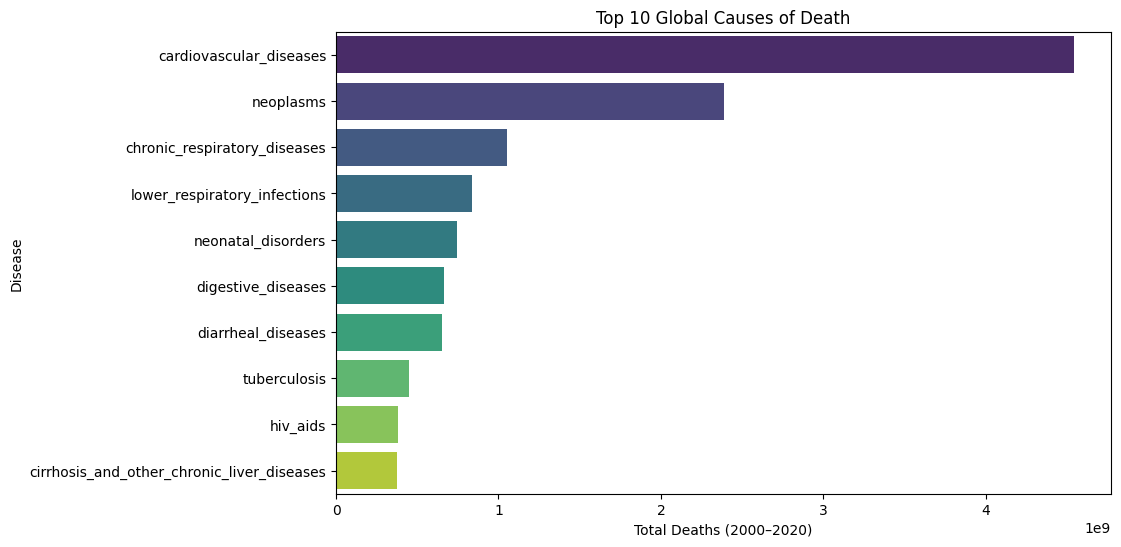

In [58]:
disease_cols = df_disease.columns[3:]

total_deaths = df_disease[disease_cols].sum().sort_values(ascending=False)

top10 = total_deaths.head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top10.values, y=top10.index, palette="viridis")
plt.title("Top 10 Global Causes of Death")
plt.xlabel("Total Deaths (2000–2020)")
plt.ylabel("Disease")
plt.show()

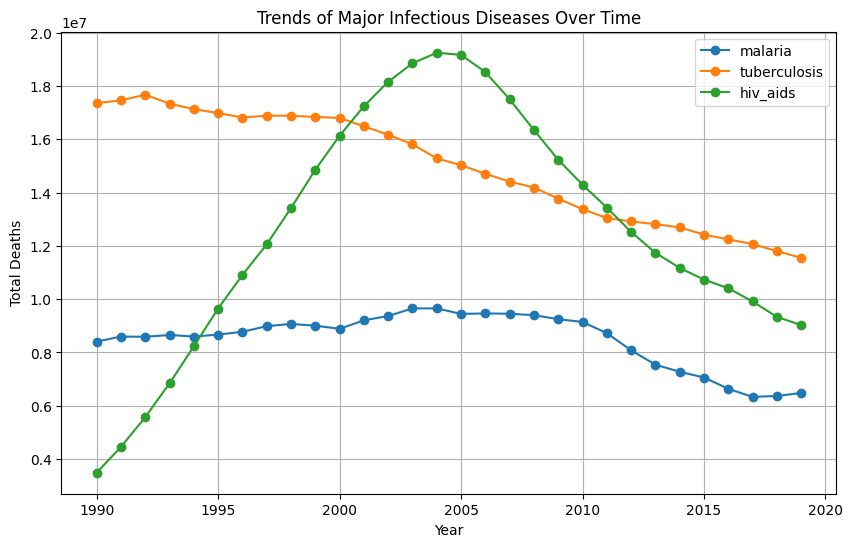

In [59]:
plt.figure(figsize=(10,6))

for disease in ["malaria", "tuberculosis", "hiv_aids"]:
    trend = df_disease.groupby("year")[disease].sum()
    plt.plot(trend.index, trend.values, marker="o", label=disease)

plt.title("Trends of Major Infectious Diseases Over Time")
plt.xlabel("Year")
plt.ylabel("Total Deaths")
plt.legend()
plt.grid(True)
plt.show()


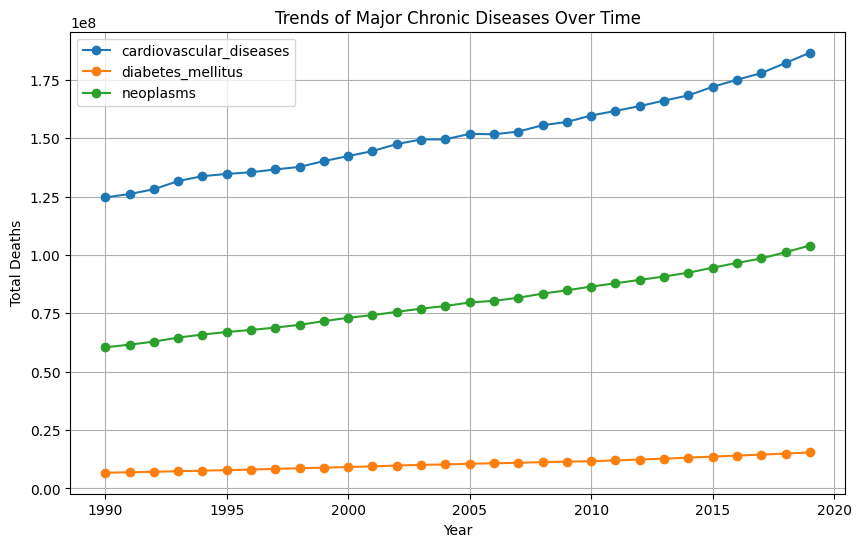

In [60]:
plt.figure(figsize=(10,6))

for disease in ["cardiovascular_diseases", "diabetes_mellitus", "neoplasms"]:
    trend = df_disease.groupby("year")[disease].sum()
    plt.plot(trend.index, trend.values, marker="o", label=disease)

plt.title("Trends of Major Chronic Diseases Over Time")
plt.xlabel("Year")
plt.ylabel("Total Deaths")
plt.legend()
plt.grid(True)
plt.show()


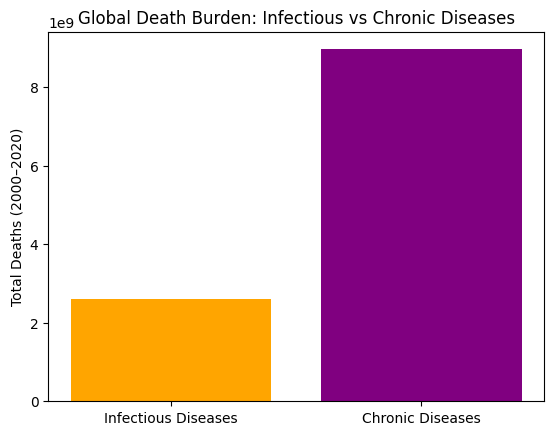

In [61]:
infectious = ["malaria", "tuberculosis", "hiv_aids", "diarrheal_diseases",
              "lower_respiratory_infections", "acute_hepatitis"]

chronic = ["cardiovascular_diseases", "neoplasms", "diabetes_mellitus",
           "chronic_respiratory_diseases", "chronic_kidney_disease",
           "cirrhosis_and_other_chronic_liver_diseases"]

infectious_total = df_disease[infectious].sum().sum()
chronic_total = df_disease[chronic].sum().sum()

plt.bar(["Infectious Diseases", "Chronic Diseases"], [infectious_total, chronic_total], color=["orange","purple"])
plt.title("Global Death Burden: Infectious vs Chronic Diseases")
plt.ylabel("Total Deaths (2000–2020)")
plt.show()


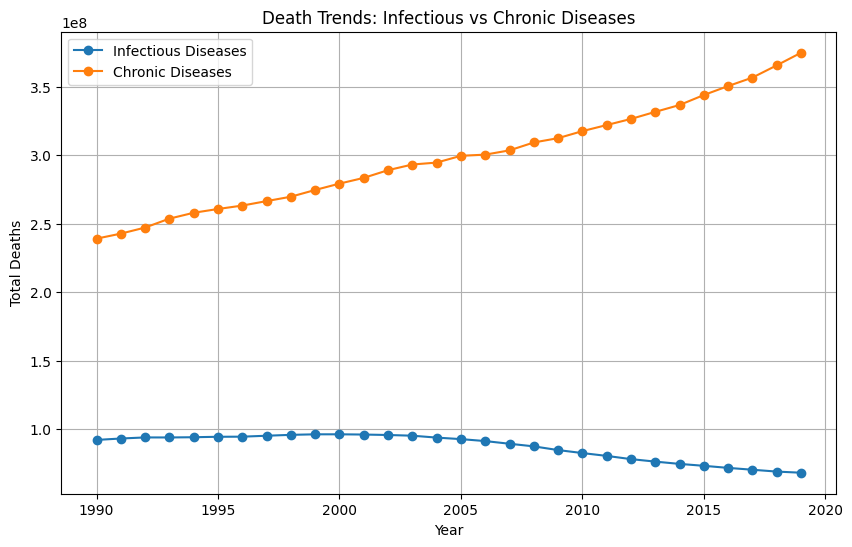

In [62]:
infectious_trend = df_disease.groupby("year")[infectious].sum().sum(axis=1)
chronic_trend = df_disease.groupby("year")[chronic].sum().sum(axis=1)

plt.figure(figsize=(10,6))
plt.plot(infectious_trend.index, infectious_trend.values, label="Infectious Diseases", marker="o")
plt.plot(chronic_trend.index, chronic_trend.values, label="Chronic Diseases", marker="o")
plt.title("Death Trends: Infectious vs Chronic Diseases")
plt.xlabel("Year")
plt.ylabel("Total Deaths")
plt.legend()
plt.grid(True)
plt.show()


In [63]:
disease_reduction = {}

for disease in disease_cols:
    yearly = df_disease.groupby("year")[disease].sum()
    disease_reduction[disease] = yearly.iloc[-1] - yearly.iloc[0]

sorted_reduction = dict(sorted(disease_reduction.items(), key=lambda x: x[1]))
print("Top 10 diseases with the largest reduction over time:")
print()
for i, (disease, change) in enumerate(list(sorted_reduction.items())[:10], 1):
    print(f"{i}. {disease}: {change}")


Top 10 diseases with the largest reduction over time:

1. diarrheal_diseases: -13173675.0
2. neonatal_disorders: -10684490.0
3. lower_respiratory_infections: -7744335.0
4. tuberculosis: -5803269.0
5. nutritional_deficiencies: -4855371.0
6. protein_energy_malnutrition: -4250581.0
7. drowning: -2164903.0
8. malaria: -1926962.0
9. meningitis: -1896486.0
10. maternal_disorders: -1028056.0


In [64]:
sorted_increase = dict(sorted(disease_reduction.items(), key=lambda x: x[1], reverse=True))
print("Top 10 diseases with the largest increase over time:")
print()
for i, (disease, change) in enumerate(list(sorted_increase.items())[:10], 1):
    print(f"{i}. {disease}: {change}")


Top 10 diseases with the largest increase over time:

1. cardiovascular_diseases: 61981517.0
2. neoplasms: 43622853.0
3. alzheimers_disease_and_other_dementias: 11026406.0
4. chronic_respiratory_diseases: 8875225.0
5. diabetes_mellitus: 8685387.0
6. chronic_kidney_disease: 8236691.0
7. digestive_diseases: 6964983.0
8. hiv_aids: 5540381.0
9. cirrhosis_and_other_chronic_liver_diseases: 4433028.0
10. parkinsons_disease: 2222560.0


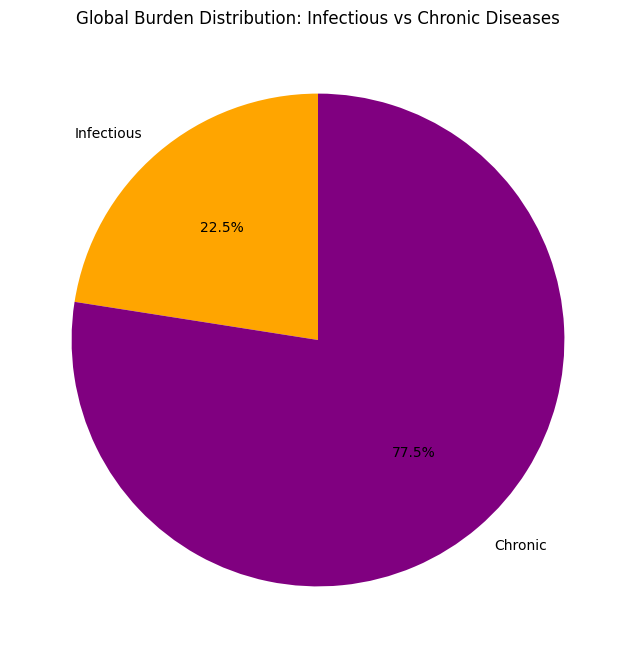

In [65]:
categories = {
    "Infectious": infectious_total,
    "Chronic": chronic_total
}

plt.figure(figsize=(8,8))
plt.pie(categories.values(), labels=categories.keys(), autopct="%1.1f%%",
        startangle=90, colors=["orange", "purple"])
plt.title("Global Burden Distribution: Infectious vs Chronic Diseases")
plt.show()


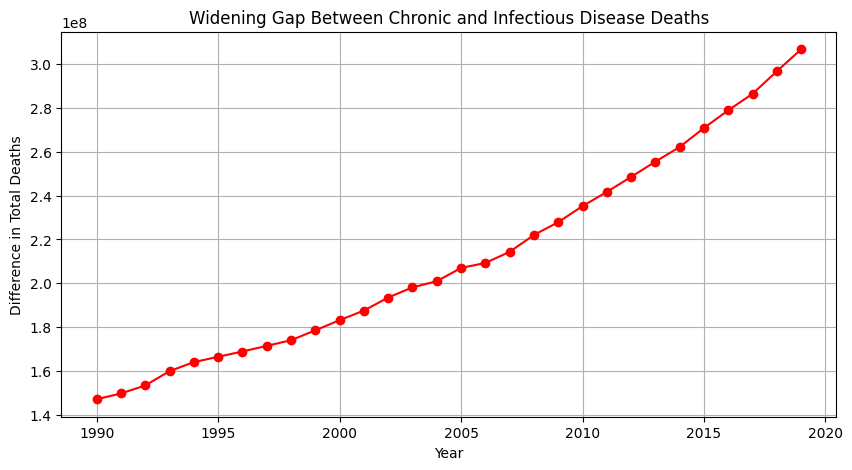

In [66]:
gap = chronic_trend - infectious_trend

plt.figure(figsize=(10,5))
plt.plot(gap.index, gap.values, marker="o", color="red")
plt.title("Widening Gap Between Chronic and Infectious Disease Deaths")
plt.xlabel("Year")
plt.ylabel("Difference in Total Deaths")
plt.grid(True)
plt.show()


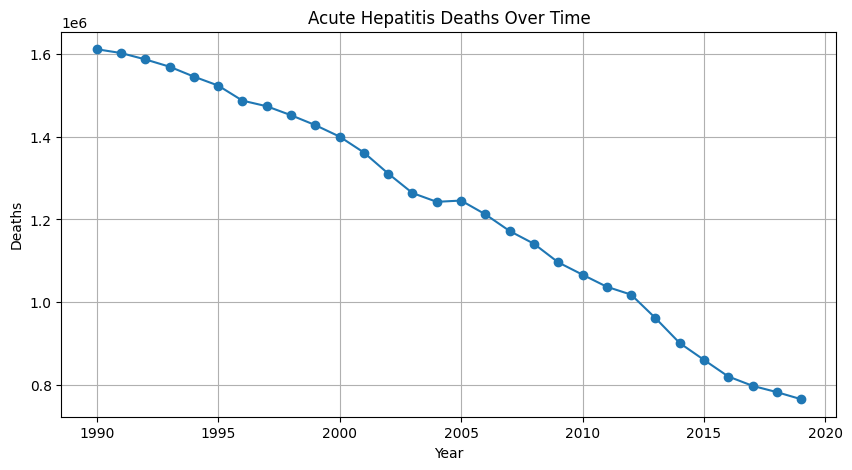

In [67]:
hep = df_disease.groupby("year")["acute_hepatitis"].sum()

plt.figure(figsize=(10,5))
plt.plot(hep.index, hep.values, marker="o")
plt.title("Acute Hepatitis Deaths Over Time")
plt.xlabel("Year")
plt.ylabel("Deaths")
plt.grid(True)
plt.show()

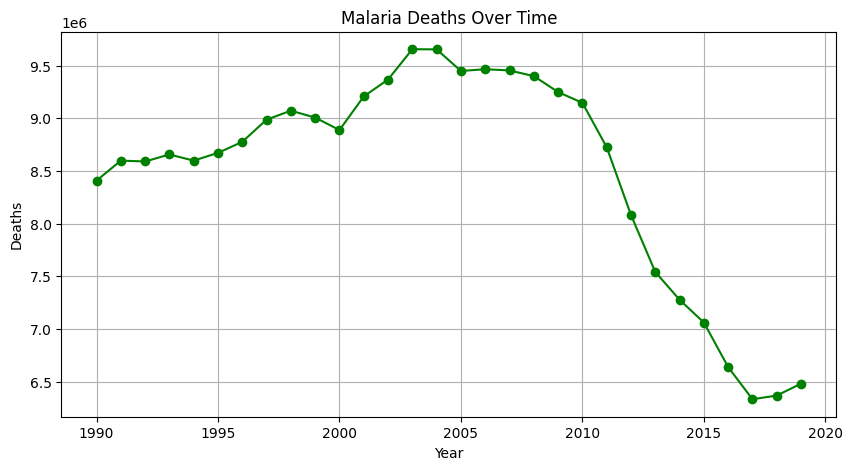

In [68]:
malaria = df_disease.groupby("year")["malaria"].sum()

plt.figure(figsize=(10,5))
plt.plot(malaria.index, malaria.values, marker="o", color="green")
plt.title("Malaria Deaths Over Time")
plt.xlabel("Year")
plt.ylabel("Deaths")
plt.grid(True)
plt.show()
